In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
DATASET_PATH = '/content/drive/MyDrive/dataset'
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
full_dataset = datasets.ImageFolder(root=DATASET_PATH, transform=transform)

print('Classes found:', full_dataset.classes)
print('Total images:', len(full_dataset))


train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size

from torch.utils.data import random_split
train_data, val_data = random_split(full_dataset, [train_size, val_size])

print(f'Training images: {train_size}  |  Validation images: {val_size}')







Classes found: ['pen', 'watch']
Total images: 60
Training images: 48  |  Validation images: 12


In [10]:
class TinyCNN(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(32 * 16 * 16, 64)
        self.fc2 = nn.Linear(64, 2)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


In [12]:
def train_model(learning_rate, batch_size, dropout_rate, num_epochs=20, experiment_name='Experiment'):
    print(f'\n Starting: {experiment_name}')
    print(f'   LR={learning_rate}, Batch={batch_size}, Dropout={dropout_rate}\n')

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_data,   batch_size=batch_size, shuffle=False)

    model = TinyCNN(dropout_rate=dropout_rate)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(num_epochs):

        model.train()
        total_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_losses.append(total_loss / len(train_loader))
        train_accs.append(correct / total)


        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                loss = loss_fn(outputs, labels)
                val_loss += loss.item()
                predicted = outputs.argmax(dim=1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(val_correct / val_total)

        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1}/{num_epochs} — '
                  f'Train Loss: {train_losses[-1]:.3f}, '
                  f'Val Loss: {val_losses[-1]:.3f}, '
                  f'Val Acc: {val_accs[-1]*100:.1f}%')

    print(f'\n Done! Final Val Accuracy: {val_accs[-1]*100:.1f}%')
    return train_losses, val_losses, train_accs, val_accs

In [13]:
def plot_results(results_dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for name, (train_losses, val_losses, train_accs, val_accs) in results_dict.items():
        axes[0].plot(train_losses, label=f'{name} - train')
        axes[0].plot(val_losses,   label=f'{name} - val', linestyle='--')
        axes[1].plot(val_accs,     label=name)

    axes[0].set_title('Loss over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].set_title('Validation Accuracy over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig('results.png', dpi=150)
    plt.show()
    print('Plot saved as results.png')

In [15]:
r1 = train_model(
    learning_rate = 0.001,
    batch_size    = 16,
    dropout_rate  = 0.0,
    experiment_name = 'Baseline'
)


 Starting: Baseline
   LR=0.001, Batch=16, Dropout=0.0

  Epoch 5/20 — Train Loss: 0.684, Val Loss: 0.676, Val Acc: 50.0%
  Epoch 10/20 — Train Loss: 0.560, Val Loss: 0.524, Val Acc: 100.0%
  Epoch 15/20 — Train Loss: 0.373, Val Loss: 0.351, Val Acc: 100.0%
  Epoch 20/20 — Train Loss: 0.297, Val Loss: 0.279, Val Acc: 100.0%

 Done! Final Val Accuracy: 100.0%


In [16]:
r2 = train_model(
    learning_rate = 0.1,
    batch_size    = 16,
    dropout_rate  = 0.0,
    experiment_name = 'High LR (unstable)'
)


 Starting: High LR (unstable)
   LR=0.1, Batch=16, Dropout=0.0

  Epoch 5/20 — Train Loss: 0.718, Val Loss: 0.702, Val Acc: 50.0%
  Epoch 10/20 — Train Loss: 0.705, Val Loss: 0.704, Val Acc: 50.0%
  Epoch 15/20 — Train Loss: 0.711, Val Loss: 0.698, Val Acc: 50.0%
  Epoch 20/20 — Train Loss: 0.697, Val Loss: 0.693, Val Acc: 50.0%

 Done! Final Val Accuracy: 50.0%


In [17]:

r3 = train_model(
    learning_rate = 0.001,
    batch_size    = 16,
    dropout_rate  = 0.5,
    experiment_name = 'With Dropout'
)


 Starting: With Dropout
   LR=0.001, Batch=16, Dropout=0.5

  Epoch 5/20 — Train Loss: 0.637, Val Loss: 0.610, Val Acc: 50.0%
  Epoch 10/20 — Train Loss: 0.396, Val Loss: 0.323, Val Acc: 100.0%
  Epoch 15/20 — Train Loss: 0.120, Val Loss: 0.056, Val Acc: 100.0%
  Epoch 20/20 — Train Loss: 0.073, Val Loss: 0.012, Val Acc: 100.0%

 Done! Final Val Accuracy: 100.0%


In [18]:
r4 = train_model(
    learning_rate = 0.001,
    batch_size    = 4,
    dropout_rate  = 0.0,
    experiment_name = 'Small Batch'
)


 Starting: Small Batch
   LR=0.001, Batch=4, Dropout=0.0

  Epoch 5/20 — Train Loss: 0.524, Val Loss: 0.345, Val Acc: 91.7%
  Epoch 10/20 — Train Loss: 0.011, Val Loss: 0.006, Val Acc: 100.0%
  Epoch 15/20 — Train Loss: 0.002, Val Loss: 0.001, Val Acc: 100.0%
  Epoch 20/20 — Train Loss: 0.001, Val Loss: 0.001, Val Acc: 100.0%

 Done! Final Val Accuracy: 100.0%


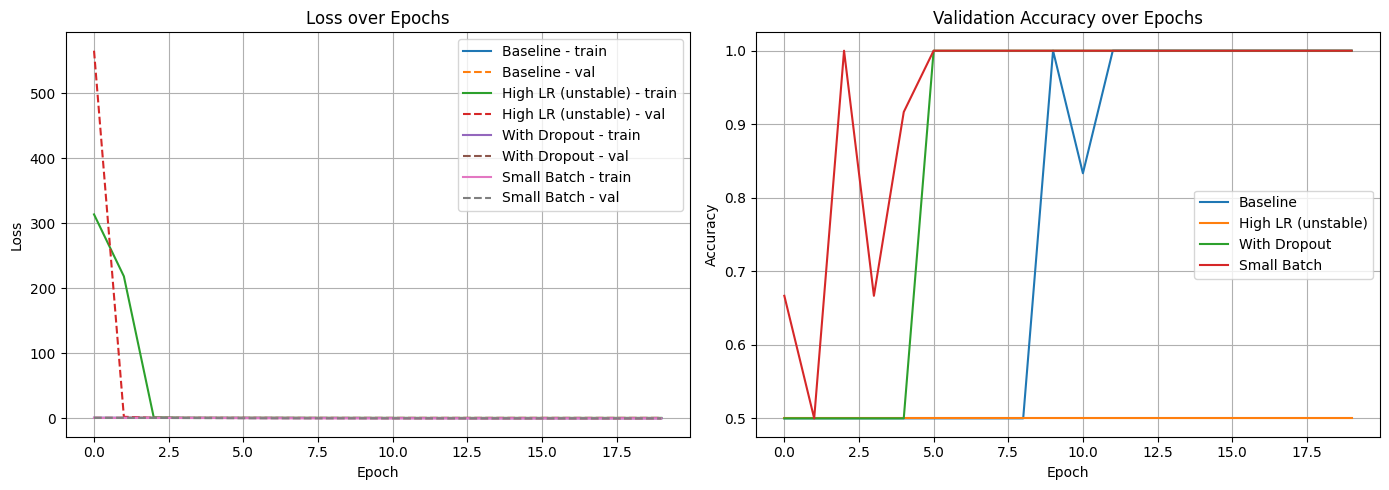

Plot saved as results.png


In [19]:
all_results = {
    'Baseline':          r1,
    'High LR (unstable)': r2,
    'With Dropout':      r3,
    'Small Batch':       r4,
}

plot_results(all_results)